In [26]:
# Təqdim edilən CSV faylı oxuyun.

In [3]:
import pandas as pd
from IPython.external.qt_loaders import QT_API_PYQTv1

df = pd.read_csv('complex_dataframe.csv')

In [5]:
print(df.head())

   Product_ID     Category   Price  Units_Sold  Store_ID  Customer_Age  \
0           1         Food  350.59          48        12            40   
1           2    Furniture  270.37          66        16            56   
2           3  Electronics  158.22          70         1            34   
3           4         Food  407.83          28         3            51   
4           5         Food  343.94          93        20            58   

  Customer_Gender  Discount_Applied Purchase_Date  Satisfaction_Score  
0            Male                 5    2022-01-01                   2  
1            Male                 5    2022-01-02                   2  
2          Female                 0    2022-01-03                   3  
3            Male                 5    2022-01-04                   5  
4            Male                20    2022-01-05                   5  


In [28]:
# 1. DataFrame-də ən yüksək qiymətli məhsulu (Price) və bu məhsulun kateqoriyasını tapın.

In [15]:
maxprice = df['Price'].max()
print(maxprice)
max_price_row = df.loc[df["Price"].idxmax()]
print(max_price_row['Category'])

499.86
Electronics


In [30]:
# 2. DataFrame-də endirim edilmiş qiyməti (Price - Discount_Applied) hesablayaraq yeni bir sütun əlavə edin.

In [18]:
df['Discount Price'] = df['Price'] - df['Discount_Applied']
print(df['Discount Price'].head())

0    345.59
1    265.37
2    158.22
3    402.83
4    323.94
Name: Discount Price, dtype: float64


In [32]:
# 3. Müştəri yaş qruplarını (18-30, 31-50, 51-70) təsnif edin və onları yeni bir sütunda qeyd edin.

In [20]:
df['Age Group'] = df['Customer_Age'].apply(lambda x: '18-30' if 18 <= x <= 30 else '31-50' if 31 <= x <= 50 else '51 - 70' if 51 <= x <= 70 else 'Other')
print(df['Age Group'].head())

0      31-50
1    51 - 70
2      31-50
3    51 - 70
4    51 - 70
Name: Age Group, dtype: object


In [34]:
# 4. DataFrame-də 10 ən çox məhsul satan mağazanın (Store_ID) siyahısını göstərin.

In [22]:
print(df.groupby('Store_ID')['Units_Sold'].sum().nlargest(10))

Store_ID
17    3011
9     2964
13    2910
12    2694
3     2659
20    2586
14    2567
15    2540
4     2507
8     2492
Name: Units_Sold, dtype: int64


In [36]:
# 5. Müştəri məmnuniyyəti (Satisfaction_Score) 4-dən yuxarı olan müştərilərin ortalama yaşı nə qədərdir?

In [23]:
sat = df[df['Satisfaction_Score'] > 4]
print(sat['Customer_Age'].mean())

41.839622641509436


In [38]:
# 6. Müştəri yaşları (Customer_Age) üzrə ortalama, median və standart deviation hesablayın.

In [24]:
print(df['Customer_Age'].describe())

count    1000.000000
mean       43.310000
std        14.890521
min        18.000000
25%        31.000000
50%        43.000000
75%        56.250000
max        69.000000
Name: Customer_Age, dtype: float64


In [40]:
# 7. Satılan vahidlərin (Units_Sold) 90-cı percentilini tapın.

In [25]:
print(df["Units_Sold"].quantile(0.9))

89.0


In [26]:
# 8. Satılan məhsul qiymətlərində (Price) ekstremal dəyərləri (outliers) tapmaq üçün IQR metodundan istifadə edin.

In [29]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]
print(outliers)

Empty DataFrame
Columns: [Product_ID, Category, Price, Units_Sold, Store_ID, Customer_Age, Customer_Gender, Discount_Applied, Purchase_Date, Satisfaction_Score, Discount Price, Age Group]
Index: []


In [31]:
# 9. Müştəri məmnuniyyət göstəricisinin (Satisfaction_Score) paylanmasını göstərən histogram yaradın.

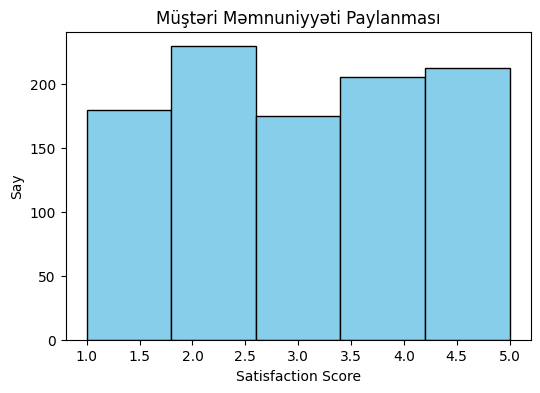

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.hist(df["Satisfaction_Score"], bins=5, color='skyblue', edgecolor='black')
plt.title("Müştəri Məmnuniyyəti Paylanması")
plt.xlabel("Satisfaction Score")
plt.ylabel("Say")
plt.show()